In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from persiantools.jdatetime import JalaliDate
from datetime import datetime
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import openpyxl
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import Label
from bokeh.models import ColumnDataSource
from bokeh.transform import dodge
from bokeh.io import output_notebook
from bokeh.models import NumeralTickFormatter
from bokeh.models import Label
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import random
import matplotlib as mpl
import seaborn as sns
import numpy as np
df = pd.read_excel("/Users/mohammad/XAV/Departemant Financial/Receipt Database.xlsx")



# Sale Trend Over Years

## Sale in a glance

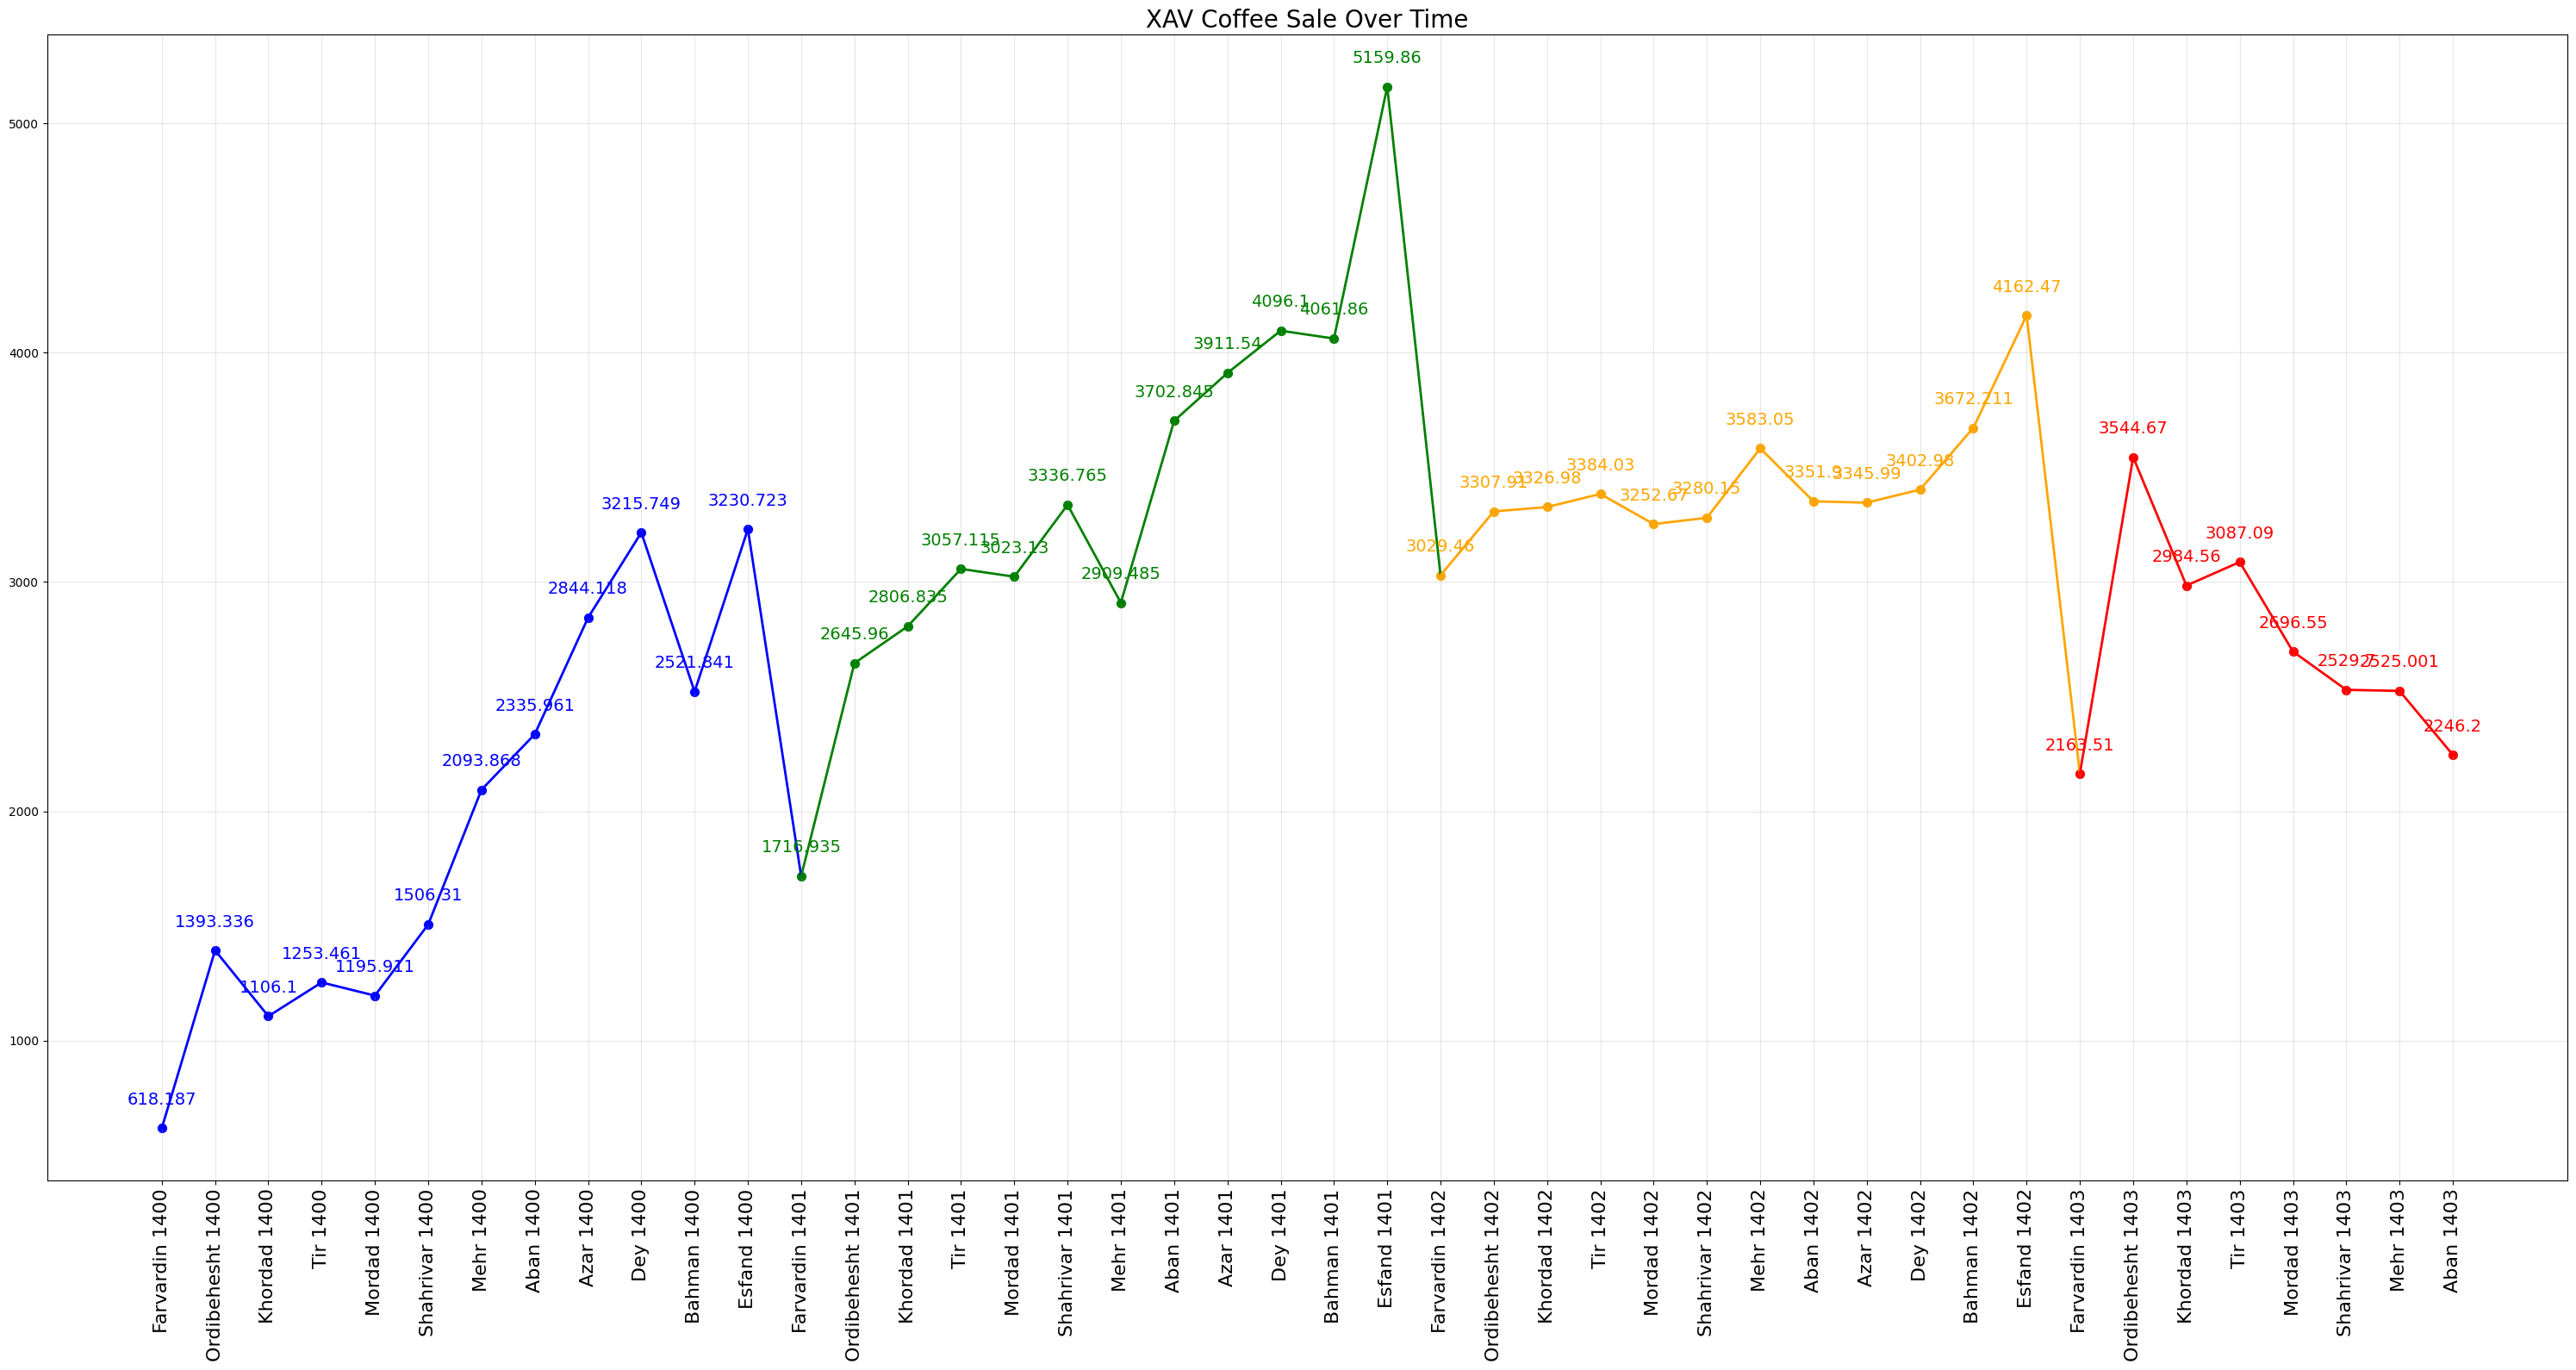

In [18]:
# creating a def to create a dict for each year ({month : kg})
def monthly_buy (year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]
    df_year['مقدار-فرعي'] = df_year['مقدار-فرعي'].fillna(0)

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # adding Each month kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"]==i]["مقدار-فرعي"].to_list())/1000,3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())
monthly_kg_1402 = list(monthly_buy("1402").values())
monthly_kg_1401 = list(monthly_buy("1401").values())
monthly_kg_1400 = list(monthly_buy("1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban" ]



# Function to calculate the average kg per year
def calculate_yearly_avg(year, monthly_data):
    return sum(monthly_data) / len(monthly_data)

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}
year_avg = {}  # To store the average for each year

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))
    
    # Calculate the average kg for this year
    year_avg[year] = calculate_yearly_avg(year, monthly_data)

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )

# Add colored markers and annotations for each point
for i, (value, color) in enumerate(zip(all_kg, colors)):
    plt.scatter(i, value, color=color, s=50)  # Markers for each point
    plt.text(
        i, 
        value + (max(all_kg) * 0.02),  # Position annotation slightly above the point
        f"{value}", 
        ha='center', 
        fontsize=14, 
        color=color
    )

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


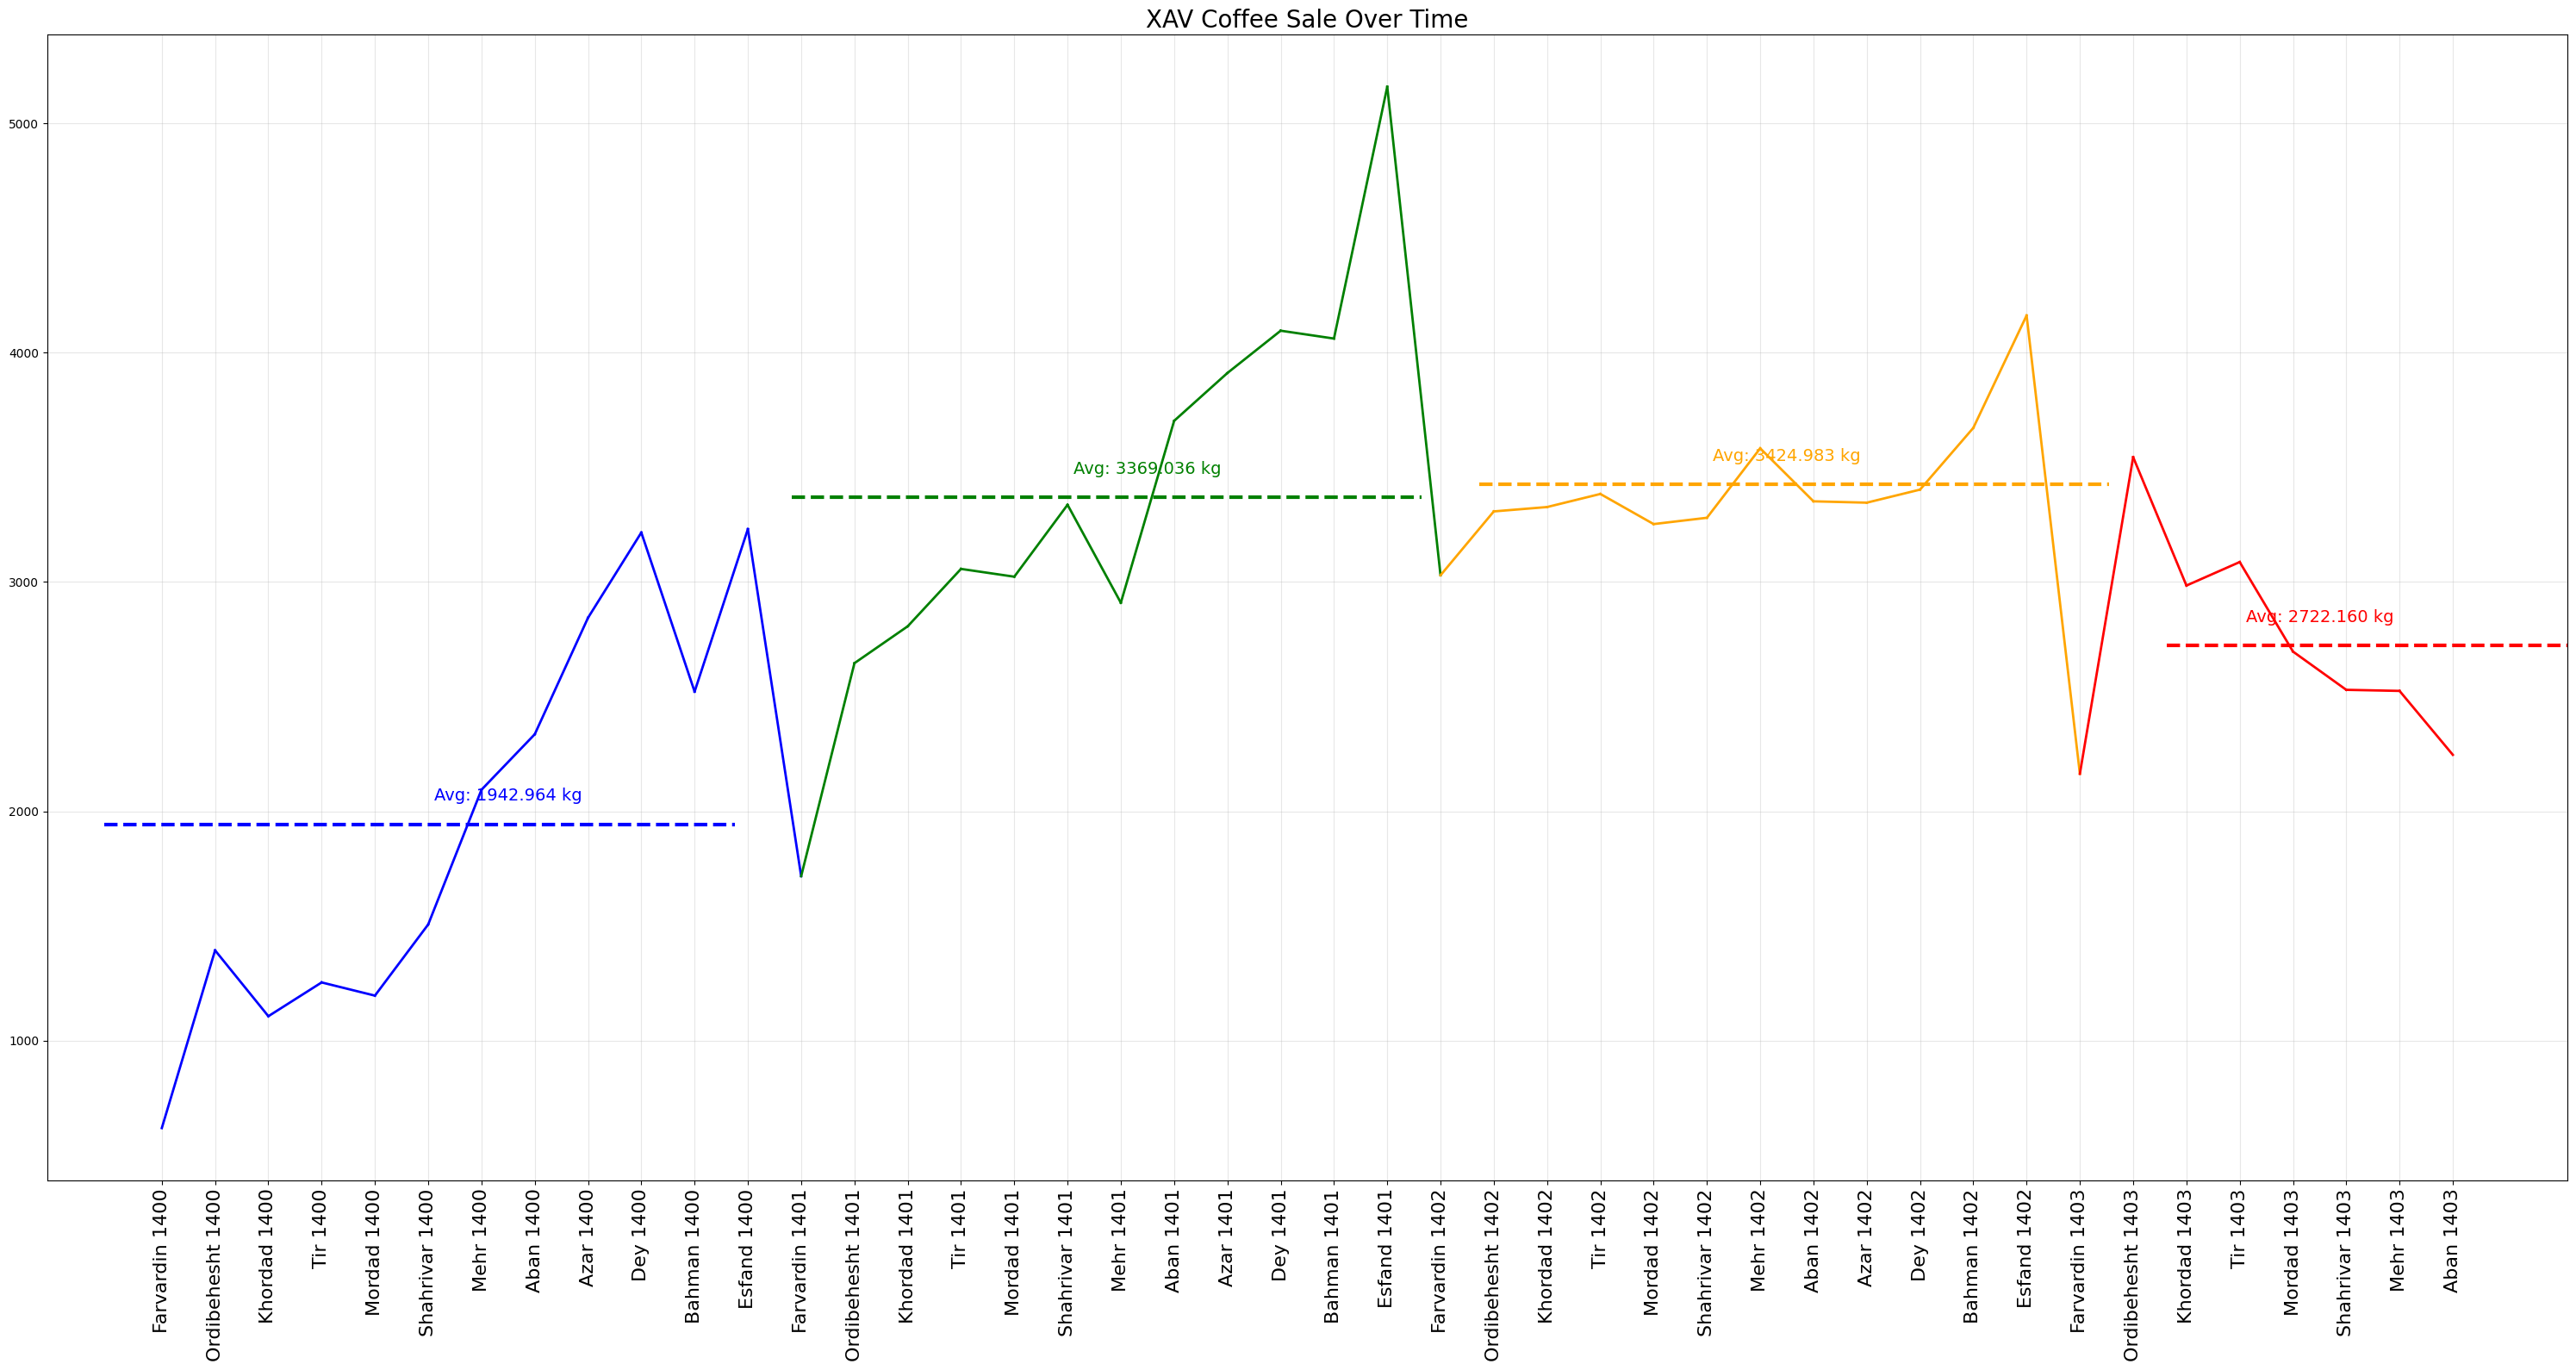

In [29]:
# creating a def to create a dict for each year ({month : kg})
def monthly_buy (year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]
    df_year['مقدار-فرعي'] = df_year['مقدار-فرعي'].fillna(0)

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # adding Each month kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"]==i]["مقدار-فرعي"].to_list())/1000,3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())
monthly_kg_1402 = list(monthly_buy("1402").values())
monthly_kg_1401 = list(monthly_buy("1401").values())
monthly_kg_1400 = list(monthly_buy("1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar',"Mehr", "Aban"]



# Function to calculate the average kg per year
def calculate_yearly_avg(year, monthly_data):
    return sum(monthly_data) / len(monthly_data)

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}
year_avg = {}  # To store the average for each year

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))
    
    # Calculate the average kg for this year
    year_avg[year] = calculate_yearly_avg(year, monthly_data)

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )


# Add horizontal lines for each year's average
index_start = 1
for year, monthly_data in yearly_kg_dict.items():
    # Calculate the position of the average (y-value) for this year
    avg_kg = year_avg[year]
    
    # Get the range of x-values for the current year
    index_end = index_start + len(monthly_data) -1
    
    # Plot the horizontal line at the average kg for this year
    plt.axhline(y=avg_kg, color=year_colors[year], linestyle='--', linewidth=3, xmin=index_start / len(all_kg), xmax=index_end / len(all_kg))
    
    # Annotate the average line with the average value
    plt.text(
        index_start + (index_end - index_start) / 2, 
        avg_kg + (max(all_kg) * 0.02),  # Position annotation slightly above the line
        f"Avg: {avg_kg:.3f} kg", 
        ha='center', 
        fontsize=14, 
        color=year_colors[year]
    )
    
    # Update the start index for the next year
    index_start = index_end +1

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


## Sales in first half f the year (bar plot)

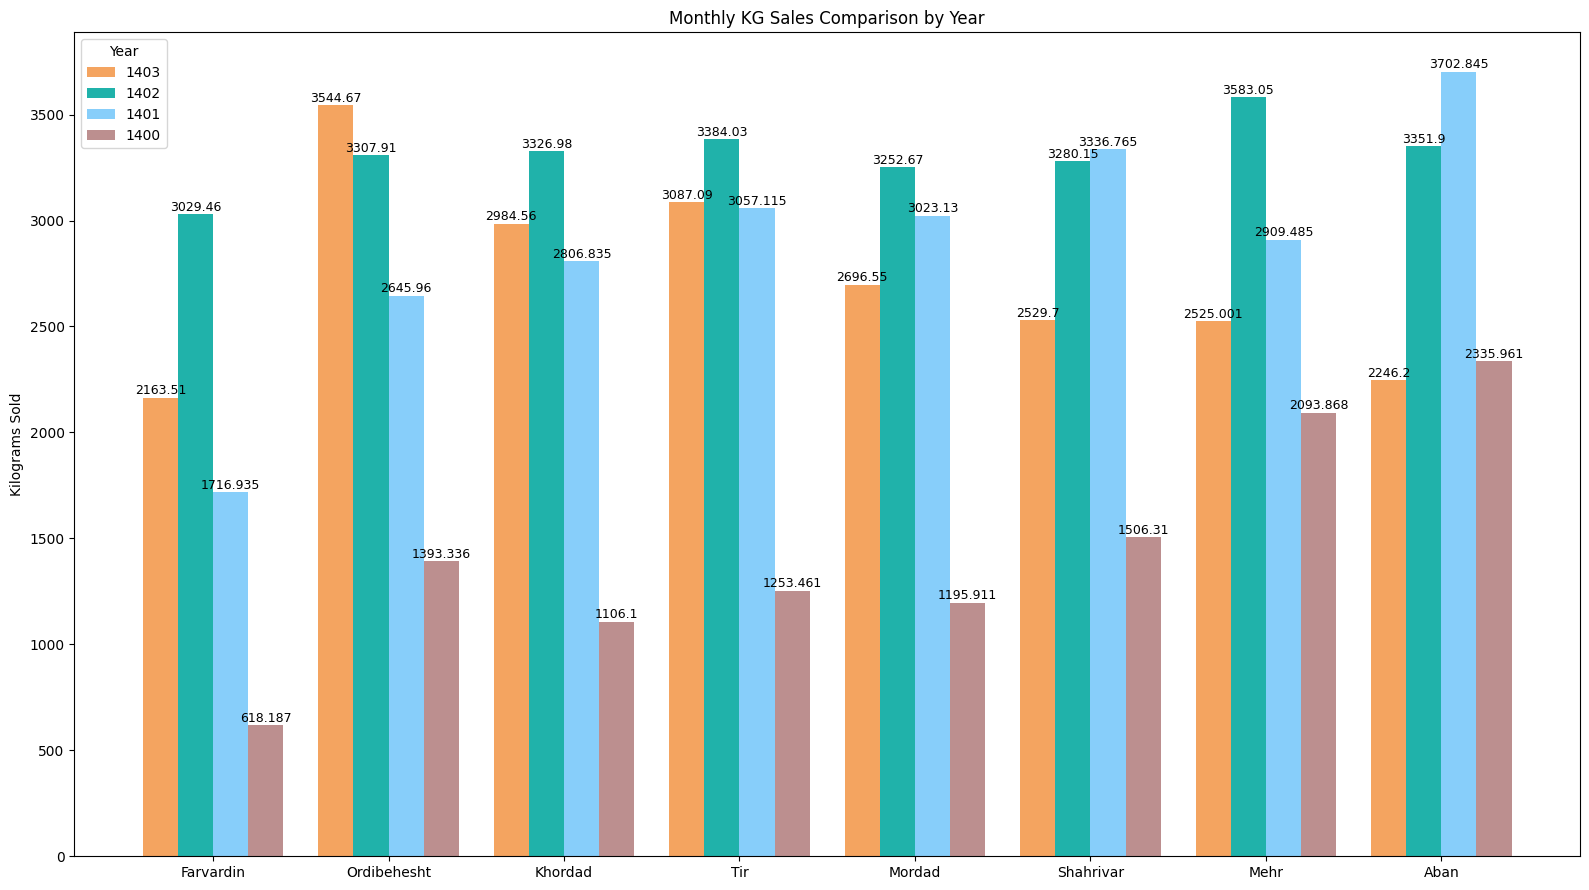

In [21]:
monthly_kg_1403 = monthly_kg_1403[:8]
monthly_kg_1402 = monthly_kg_1402[:8]
monthly_kg_1401 = monthly_kg_1401[:8]
monthly_kg_1400 = monthly_kg_1400[:8]

yearly_kg_dict = {1403: monthly_kg_1403, 1402:monthly_kg_1402, 1401:monthly_kg_1401 , 1400:monthly_kg_1400 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar',"Mehr", "Aban"]

# Plotting
x = np.arange(len(months))  # Month positions on x-axis
width = 0.2  # Bar width
# Updated colors with nude tones"
colors = ['sandybrown', 'lightseagreen', 'lightskyblue', 'rosybrown']

fig, ax = plt.subplots(figsize=(16, 9))

for i, (year, data) in enumerate(yearly_kg_dict.items()):
    bars = ax.bar(x + i * width, data, width, label=str(year), color=colors[i])
    # Adding value annotations on top of each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position
            bar.get_height() + 2,  # Y position (slightly above the bar)
            f'{bar.get_height()}',  # Text to display
            ha='center',  # Horizontal alignment
            va='bottom',  # Vertical alignment
            fontsize=9
        )

# Customizing the plot
ax.set_ylabel('Kilograms Sold')
ax.set_title('Monthly KG Sales Comparison by Year')
ax.set_xticks(x + width * (len(yearly_kg_dict) - 1) / 2)
ax.set_xticklabels(months)
ax.legend(title="Year")

plt.tight_layout()
plt.show()  


## Sales in first half of the year (line plot)

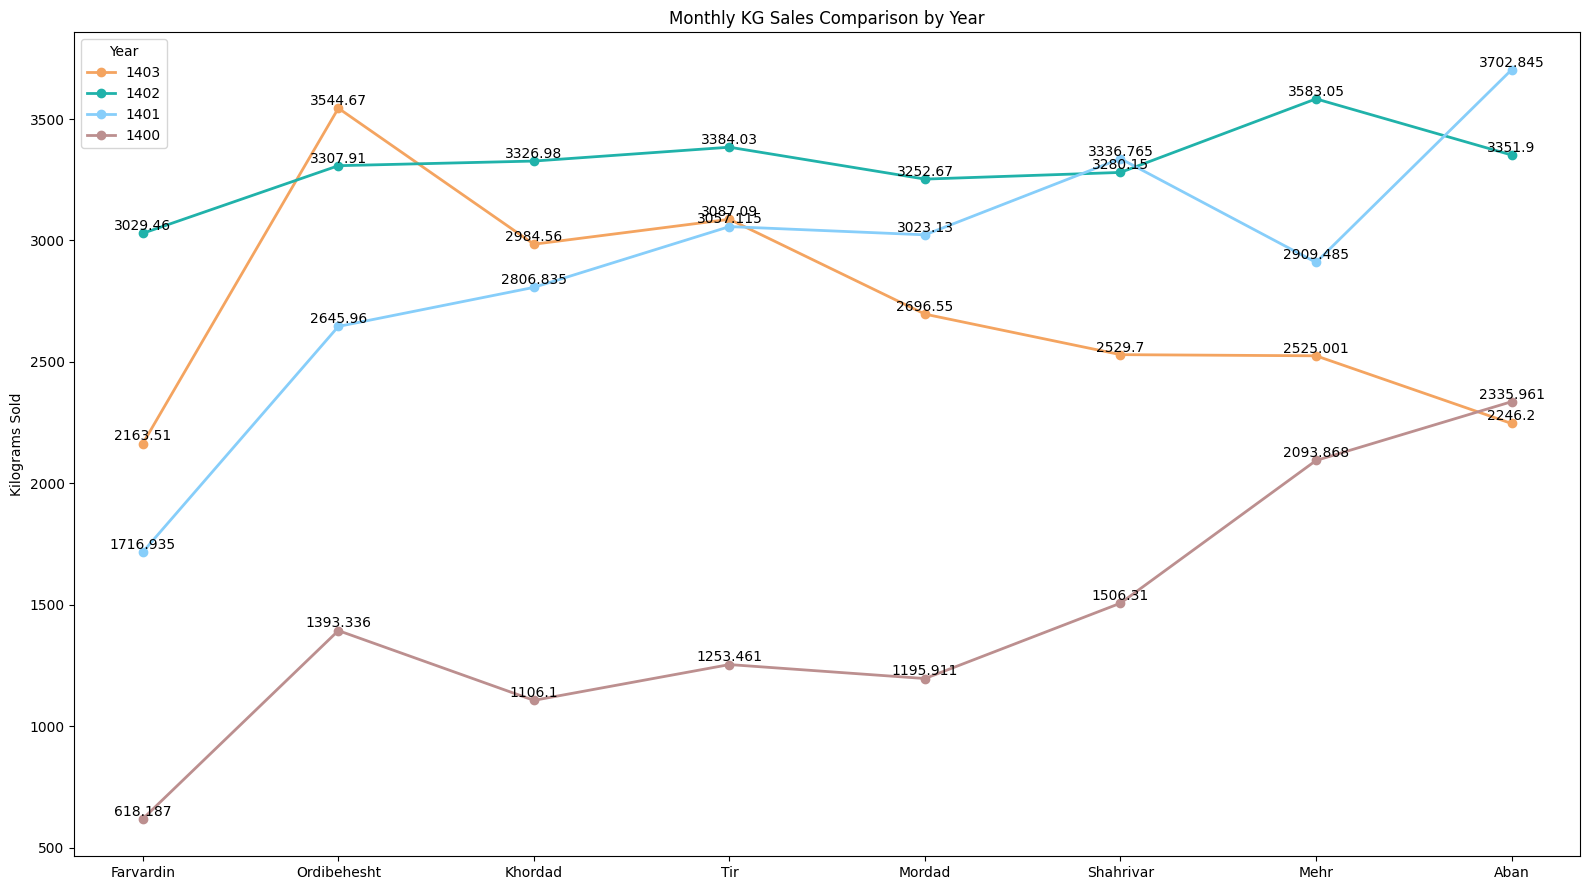

In [22]:
# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar',"Mehr", "Aban"]

# Plotting
x = np.arange(len(months))  # Month positions on x-axis

# Updated colors with soft tones
colors = ['sandybrown', 'lightseagreen', 'lightskyblue', 'rosybrown']

fig, ax = plt.subplots(figsize=(16, 9))

# Plot each year as a line chart
for i, (year, data) in enumerate(yearly_kg_dict.items()):
    ax.plot(x, data, label=str(year), color=colors[i], marker='o', linestyle='-', linewidth=2)

# Customizing the plot
ax.set_ylabel('Kilograms Sold')
ax.set_title('Monthly KG Sales Comparison by Year')
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.legend(title="Year")

# Display values on the line
for i, (year, data) in enumerate(yearly_kg_dict.items()):
    for j, value in enumerate(data):
        ax.text(x[j], value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# 80-20 Strategy?

## total share of top 20% of customers

In [23]:
# finding top 20% cafes
def top_cafe(df,string):
    mask_year = df["تاريخ"].str.startswith(string)
    df_year= df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]
    df_year['مقدار-فرعي'] = df_year['مقدار-فرعي'].fillna(0)
    
    total_kg_sale = round((sum(df_year["مقدار-فرعي"].to_list())) / 1000,3)
    cafe_buy_dict = {}
    cafe_list = set(df_year[df_year["كد گروه مشتري"] == 2]["كد مشتري"].to_list())
    for i in cafe_list:
        kg = round(sum(df_year[df_year["كد مشتري"] == i]["مقدار-فرعي"].to_list())/1000,3)
        cafe_buy_dict[i] = {"name": df_year[df_year["كد مشتري"] == i]["مشتري"].to_list()[0],
                        "kg": kg, "share_of_total": round(kg/total_kg_sale,4)*100 }
    

    index_of_top_20_percent = int(len(cafe_buy_dict) *0.2)
    top_cafe_df = pd.DataFrame(cafe_buy_dict).T
    return top_cafe_df.sort_values(by='kg', ascending=False)[:index_of_top_20_percent+1]


print("top 20 percent of our customers bought" ,round(sum(top_cafe(df, "1403")["share_of_total"].to_list()),2),"percent of our total sale in 1403" )
print("top 20 percent of our customers bought" ,round(sum(top_cafe(df, "1402")["share_of_total"].to_list()),2),"percent of our total sale in 1402" )
print("top 20 percent of our customers bought" ,round(sum(top_cafe(df, "1401")["share_of_total"].to_list()),2),"percent of our total sale in 1401" )
print("top 20 percent of our customers bought" ,round(sum(top_cafe(df, "1400")["share_of_total"].to_list()),2),"percent of our total sale in 1400" )

top 20 percent of our customers bought 80.94 percent of our total sale in 1403
top 20 percent of our customers bought 83.69 percent of our total sale in 1402
top 20 percent of our customers bought 81.45 percent of our total sale in 1401
top 20 percent of our customers bought 84.36 percent of our total sale in 1400


## sale trend of top 20% customers throughout the years

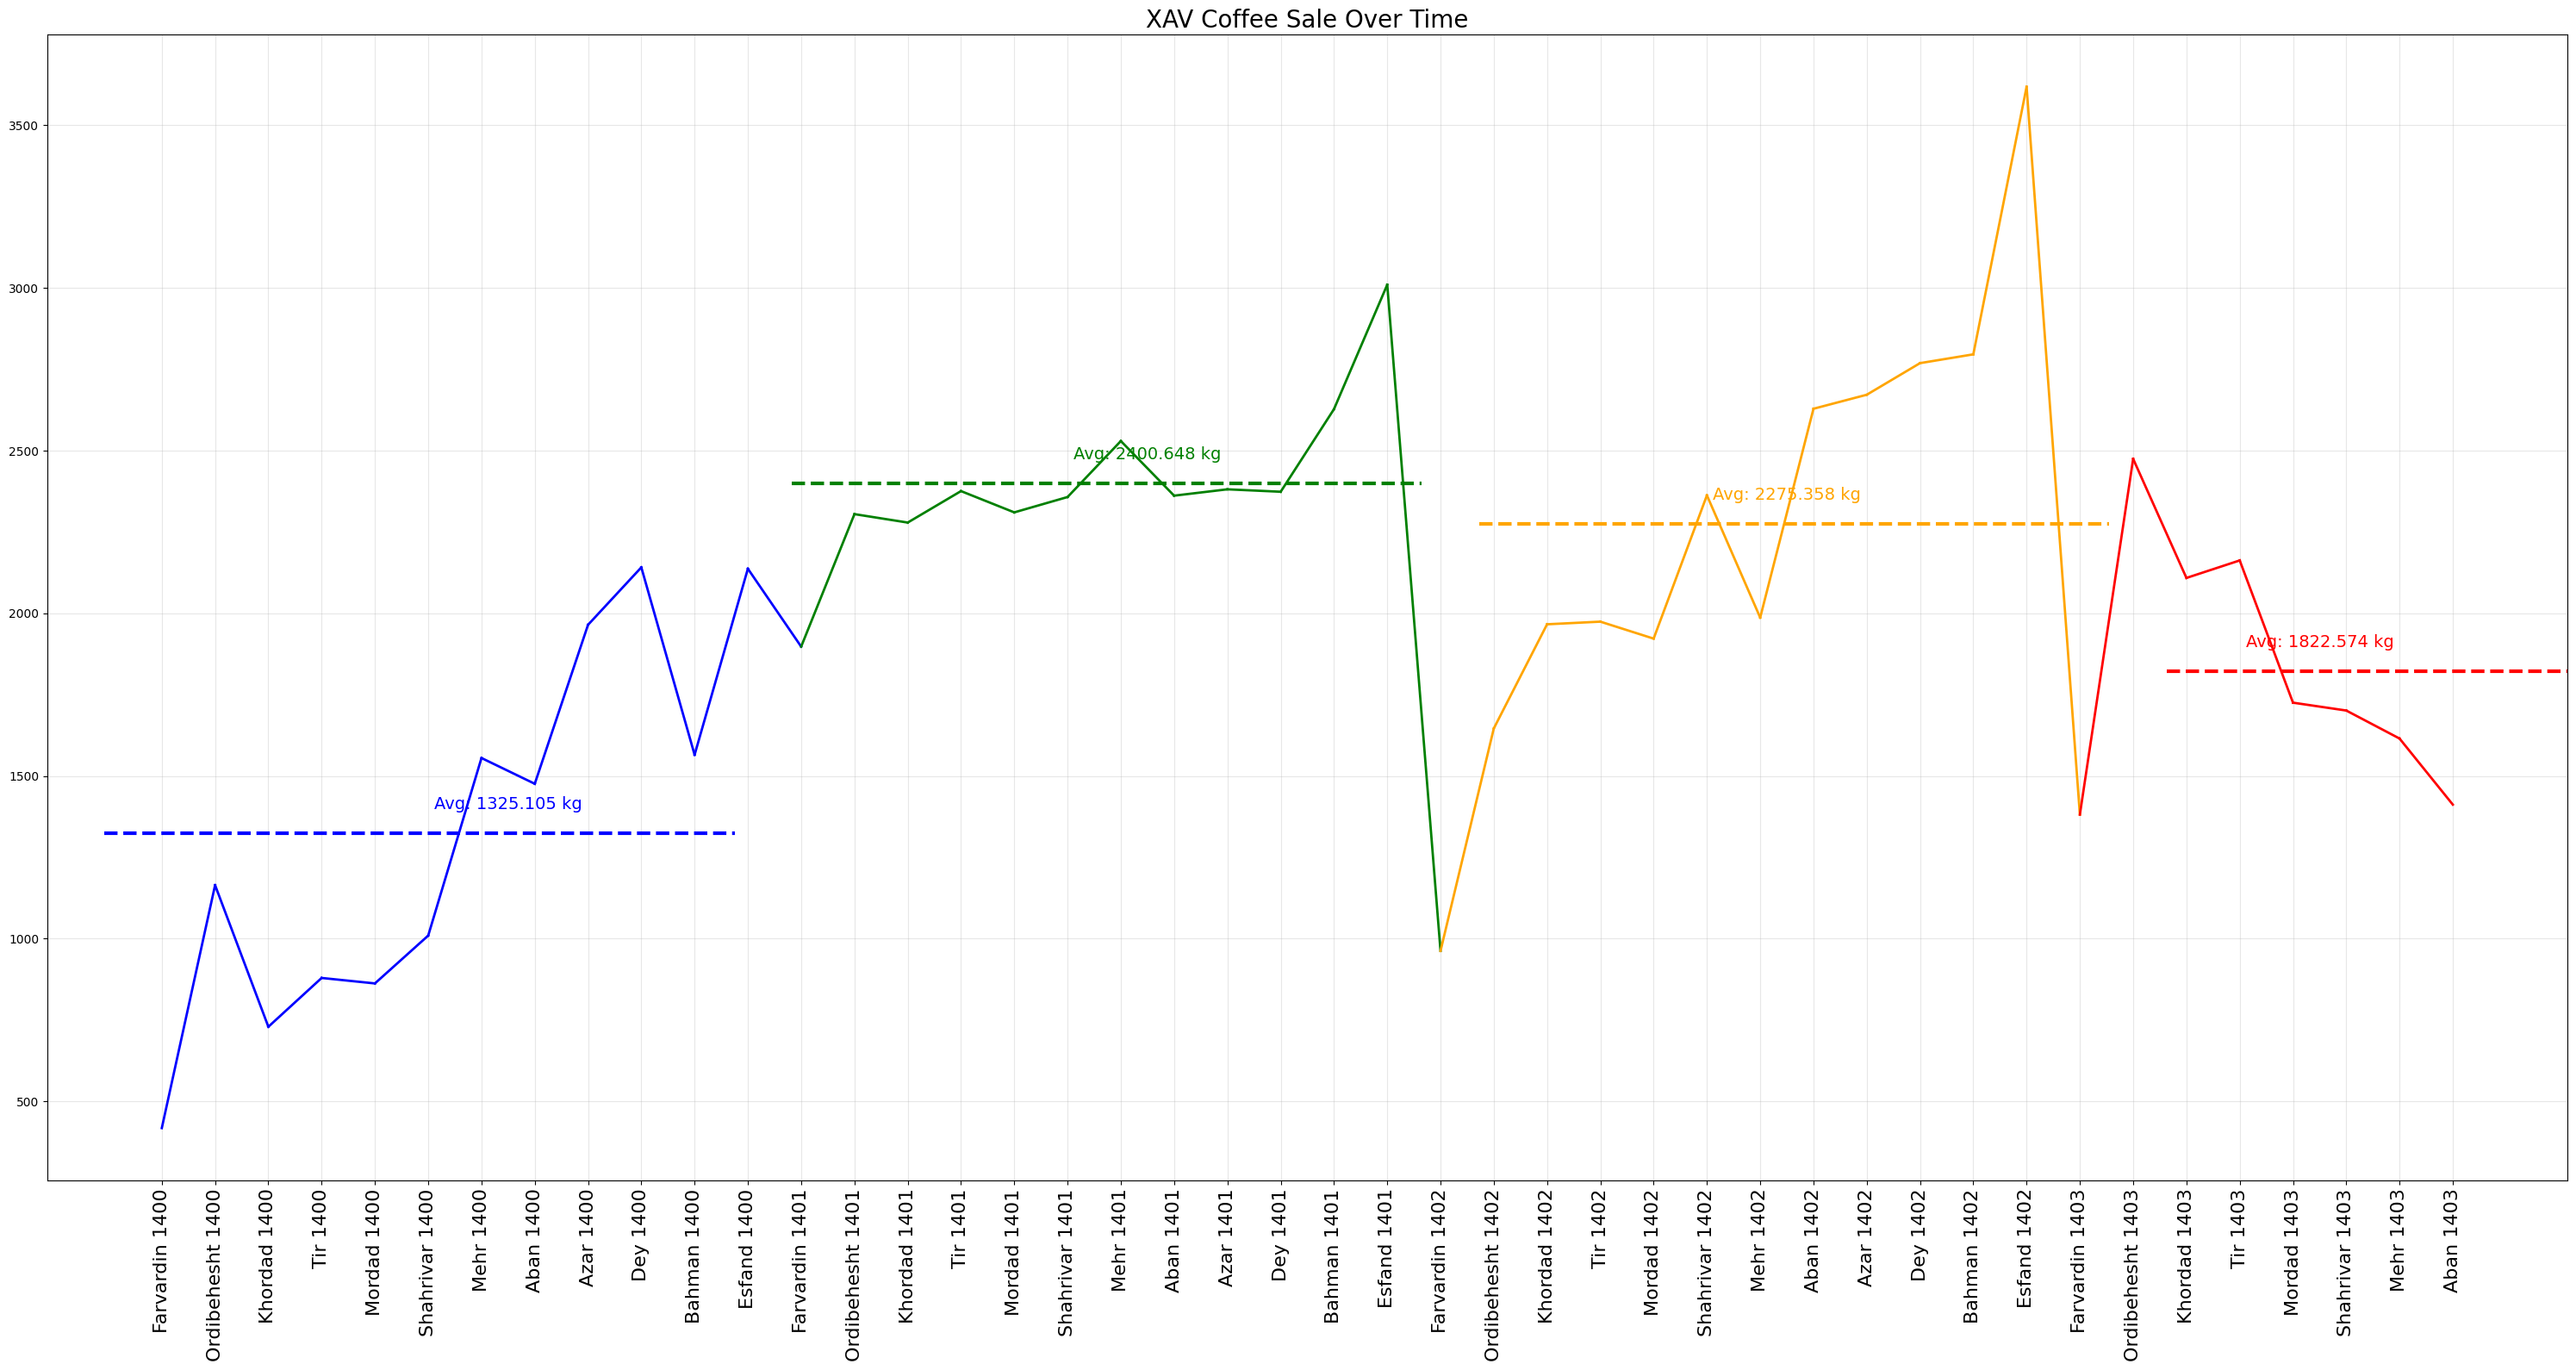

In [41]:
# find top 20% of customers i each month
def top_cafe_monthly (df,string):
    mask_year = df["تاريخ"].str.startswith(string)
    df_year= df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]
    df_year['مقدار-فرعي'] = df_year['مقدار-فرعي'].fillna(0)

    # finding all months
    months = set(df_year["ماه"].to_list())
    top_20_cafe_dict ={}
    for i in months:
        df_month = df_year[df_year["ماه"] == i]
        # finding total kg of month
        total_kg_sale = round((sum(df_month["مقدار-فرعي"].to_list())) / 1000,3)
        cafe_buy_dict = {}
        cafe_list = set(df_month[df_month["كد گروه مشتري"] == 2]["كد مشتري"].to_list())

        # itterating over all cafes and find their kg value of that month
        for j in cafe_list:
            kg = round(sum(df_month[df_month["كد مشتري"] == j]["مقدار-فرعي"].to_list())/1000,3)
            cafe_buy_dict[j] = {"name": df_month[df_month["كد مشتري"] == j]["مشتري"].to_list()[0],
                            "kg": kg, "share_of_total": round(kg/total_kg_sale,4)*100 }
        index_of_top_20_percent = int(len(cafe_buy_dict) *0.2)
        top_cafe_df = pd.DataFrame(cafe_buy_dict).T
        top_20_cafe_df = top_cafe_df.sort_values(by='kg', ascending=False)[:index_of_top_20_percent+1]
        months_kg = round(sum(top_20_cafe_df["kg"].to_list()),3)
        top_20_cafe_dict[i] = months_kg

    return top_20_cafe_dict




# plotting
monthly_kg_1403 = list(top_cafe_monthly(df,"1403").values())
monthly_kg_1402 = list(top_cafe_monthly(df,"1401").values())
monthly_kg_1401 = list(top_cafe_monthly(df,"1402").values())
monthly_kg_1400 = list(top_cafe_monthly(df,"1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban"]





# Function to calculate the average kg per year
def calculate_yearly_avg(year, monthly_data):
    return sum(monthly_data) / len(monthly_data)

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}
year_avg = {}  # To store the average for each year

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))
    
    # Calculate the average kg for this year
    year_avg[year] = calculate_yearly_avg(year, monthly_data)

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )

# # Add colored markers and annotations for each point
# for i, (value, color) in enumerate(zip(all_kg, colors)):
#     plt.scatter(i, value, color=color, s=50)  # Markers for each point
#     plt.text(
#         i, 
#         value + (max(all_kg) * 0.02),  # Position annotation slightly above the point
#         f"{value}", 
#         ha='center', 
#         fontsize=14, 
#         color=color
#     )

# Add horizontal lines for each year's average
index_start = 1
for year, monthly_data in yearly_kg_dict.items():
    # Calculate the position of the average (y-value) for this year
    avg_kg = year_avg[year]
    
    # Get the range of x-values for the current year
    index_end = index_start + len(monthly_data) -1
    
    # Plot the horizontal line at the average kg for this year
    plt.axhline(y=avg_kg, color=year_colors[year], linestyle='--', linewidth=3, xmin=index_start / len(all_kg), xmax=index_end / len(all_kg))
    
    # Annotate the average line with the average value
    plt.text(
        index_start + (index_end - index_start) / 2, 
        avg_kg + (max(all_kg) * 0.02),  # Position annotation slightly above the line
        f"Avg: {avg_kg:.3f} kg", 
        ha='center', 
        fontsize=14, 
        color=year_colors[year]
    )
    
    # Update the start index for the next year
    index_start = index_end +1

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
 

## Sale Trend of excluding top 20%

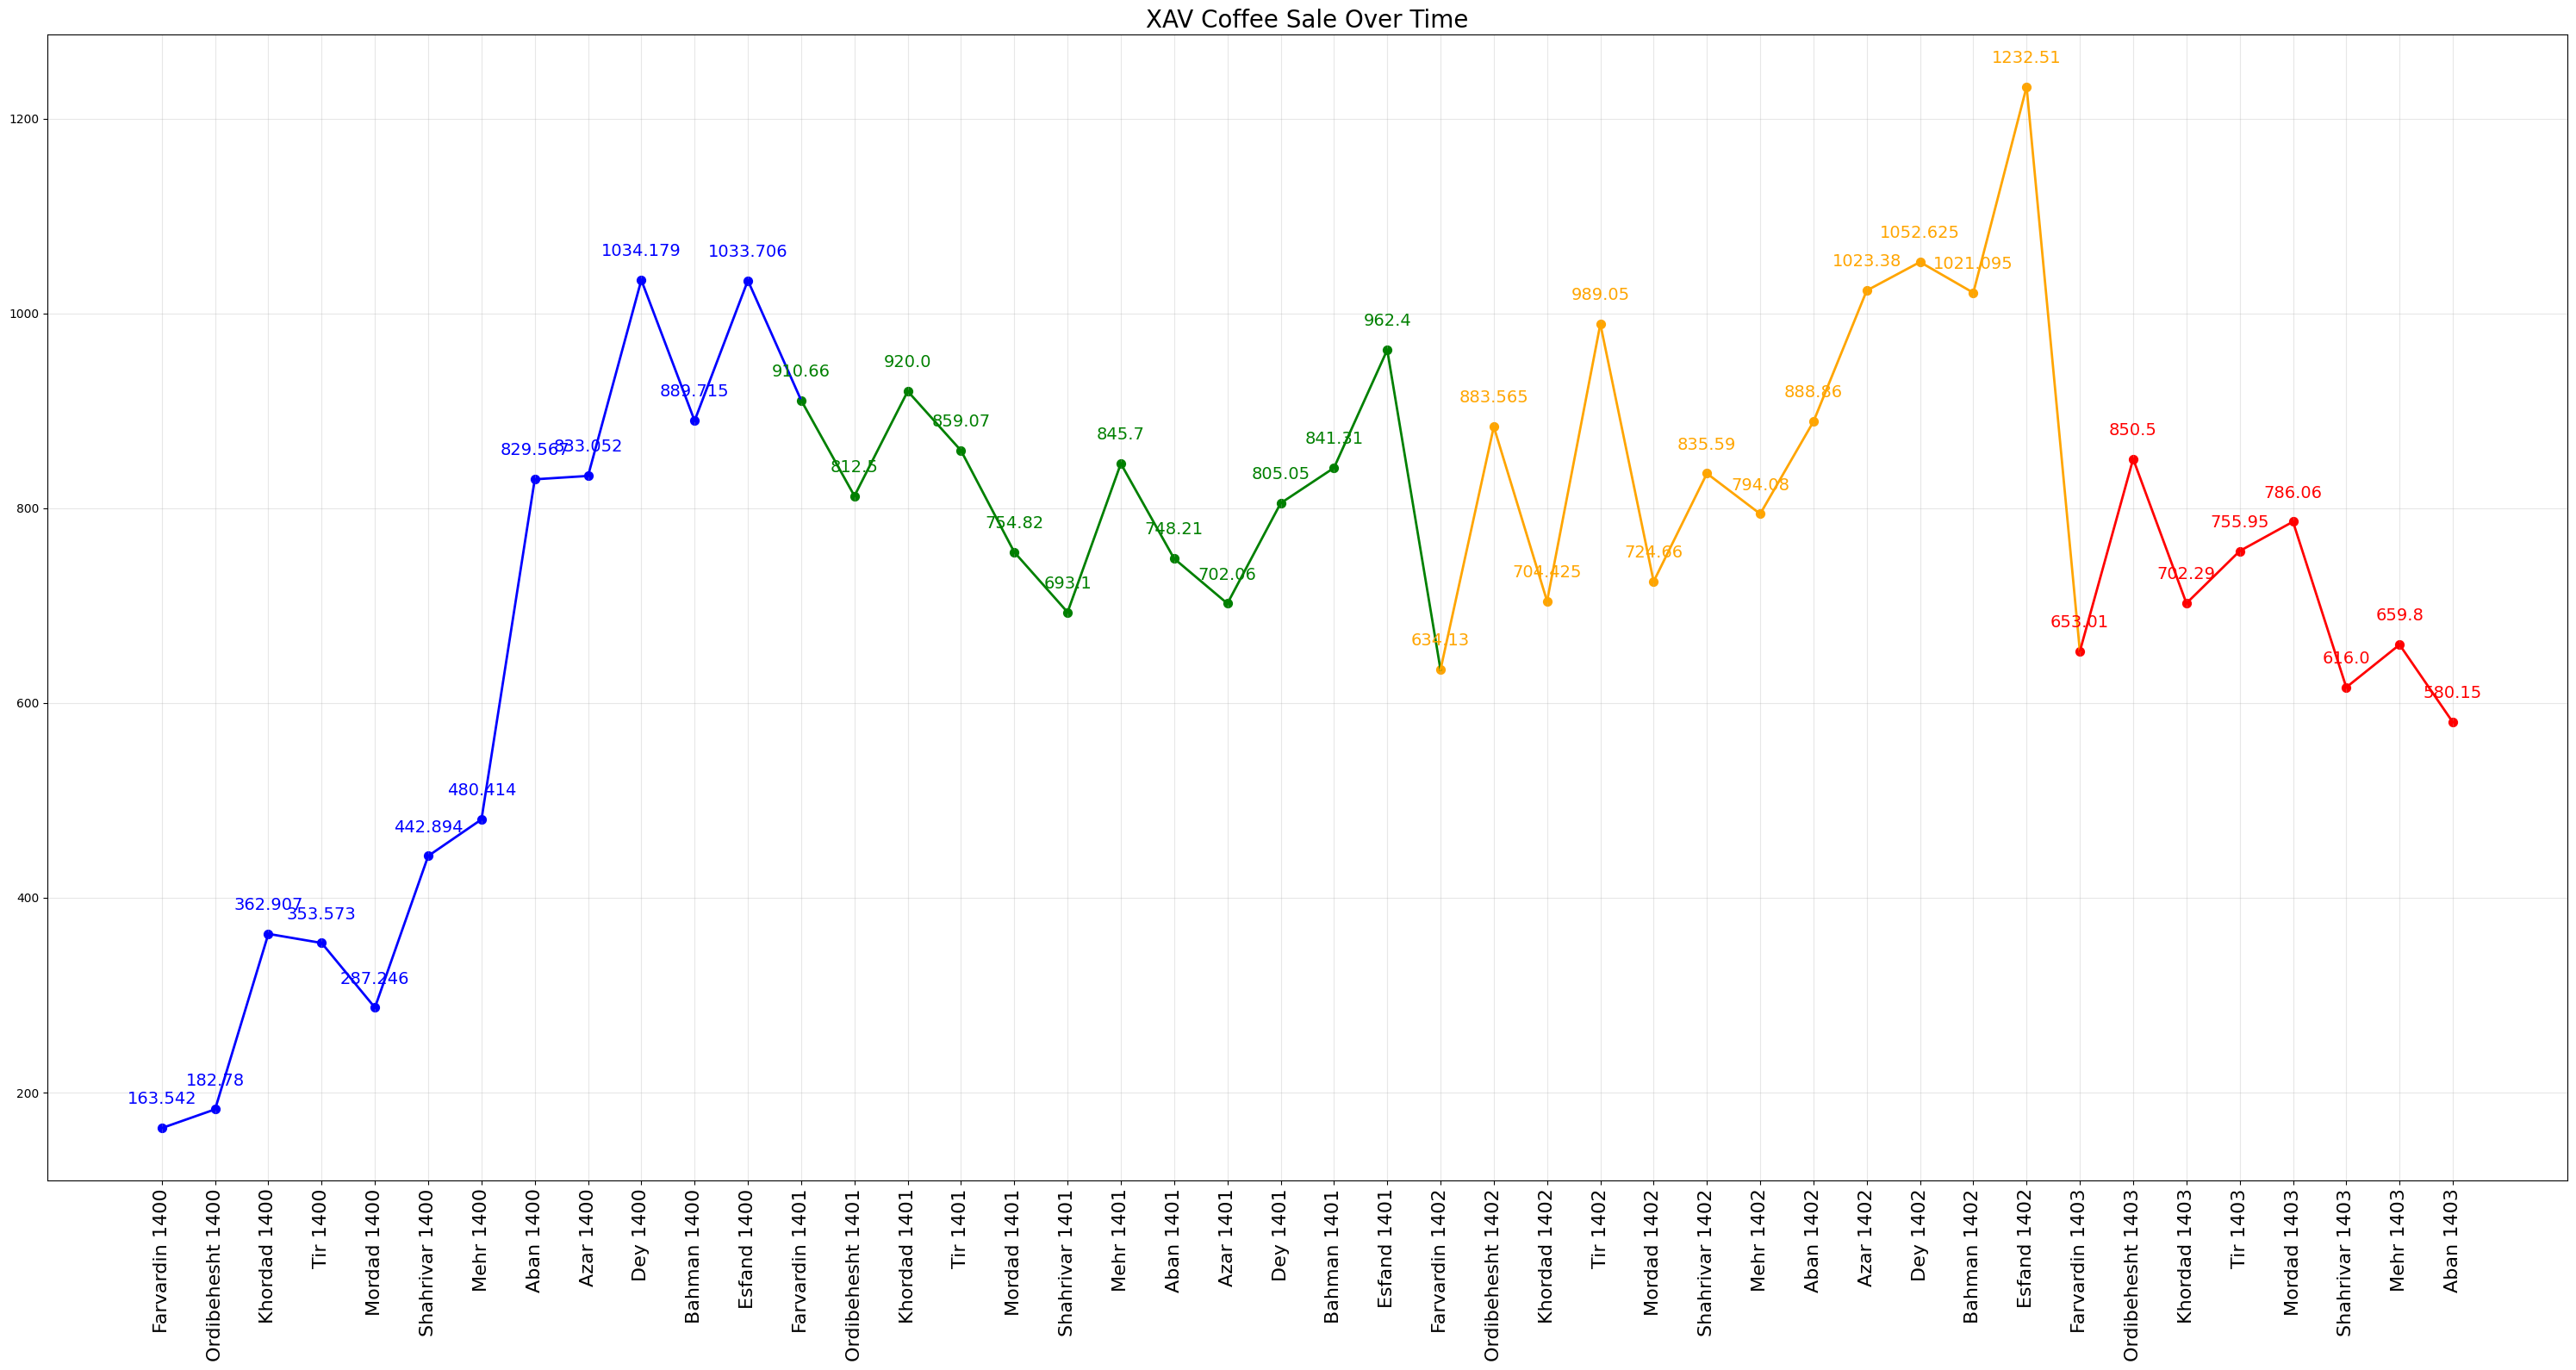

In [25]:
# find top 20% of customers i each month
def top_cafe_monthly_excluded (df,string):
    mask_year = df["تاريخ"].str.startswith(string)
    df_year= df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]
    df_year['مقدار-فرعي'] = df_year['مقدار-فرعي'].fillna(0)

    # finding all months
    months = set(df_year["ماه"].to_list())
    top_20_cafe_dict ={}
    for i in months:
        df_month = df_year[df_year["ماه"] == i]
        # finding total kg of month
        total_kg_sale = round((sum(df_month["مقدار-فرعي"].to_list())) / 1000,3)
        cafe_buy_dict = {}
        cafe_list = set(df_month[df_month["كد گروه مشتري"] == 2]["كد مشتري"].to_list())

        # itterating over all cafes and find their kg value of that month
        for j in cafe_list:
            kg = round(sum(df_month[df_month["كد مشتري"] == j]["مقدار-فرعي"].to_list())/1000,3)
            cafe_buy_dict[j] = {"name": df_month[df_month["كد مشتري"] == j]["مشتري"].to_list()[0],
                            "kg": kg, "share_of_total": round(kg/total_kg_sale,4)*100 }
        index_of_top_20_percent = int(len(cafe_buy_dict) *0.2)
        top_cafe_df = pd.DataFrame(cafe_buy_dict).T
        top_20_cafe_df = top_cafe_df.sort_values(by='kg', ascending=False)[index_of_top_20_percent:]
        months_kg = round(sum(top_20_cafe_df["kg"].to_list()),3)
        top_20_cafe_dict[i] = months_kg

    return top_20_cafe_dict




# plotting
monthly_kg_1403 = list(top_cafe_monthly_excluded(df,"1403").values())
monthly_kg_1402 = list(top_cafe_monthly_excluded(df,"1401").values())
monthly_kg_1401 = list(top_cafe_monthly_excluded(df,"1402").values())
monthly_kg_1400 = list(top_cafe_monthly_excluded(df,"1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }


# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", "Esfand",
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar']





# Function to calculate the average kg per year
def calculate_yearly_avg(year, monthly_data):
    return sum(monthly_data) / len(monthly_data)

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}
year_avg = {}  # To store the average for each year

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))
    
    # Calculate the average kg for this year
    year_avg[year] = calculate_yearly_avg(year, monthly_data)

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )

# Add colored markers and annotations for each point
for i, (value, color) in enumerate(zip(all_kg, colors)):
    plt.scatter(i, value, color=color, s=50)  # Markers for each point
    plt.text(
        i, 
        value + (max(all_kg) * 0.02),  # Position annotation slightly above the point
        f"{value}", 
        ha='center', 
        fontsize=14, 
        color=color
    )

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
 

# Price Changes

## show on trend 

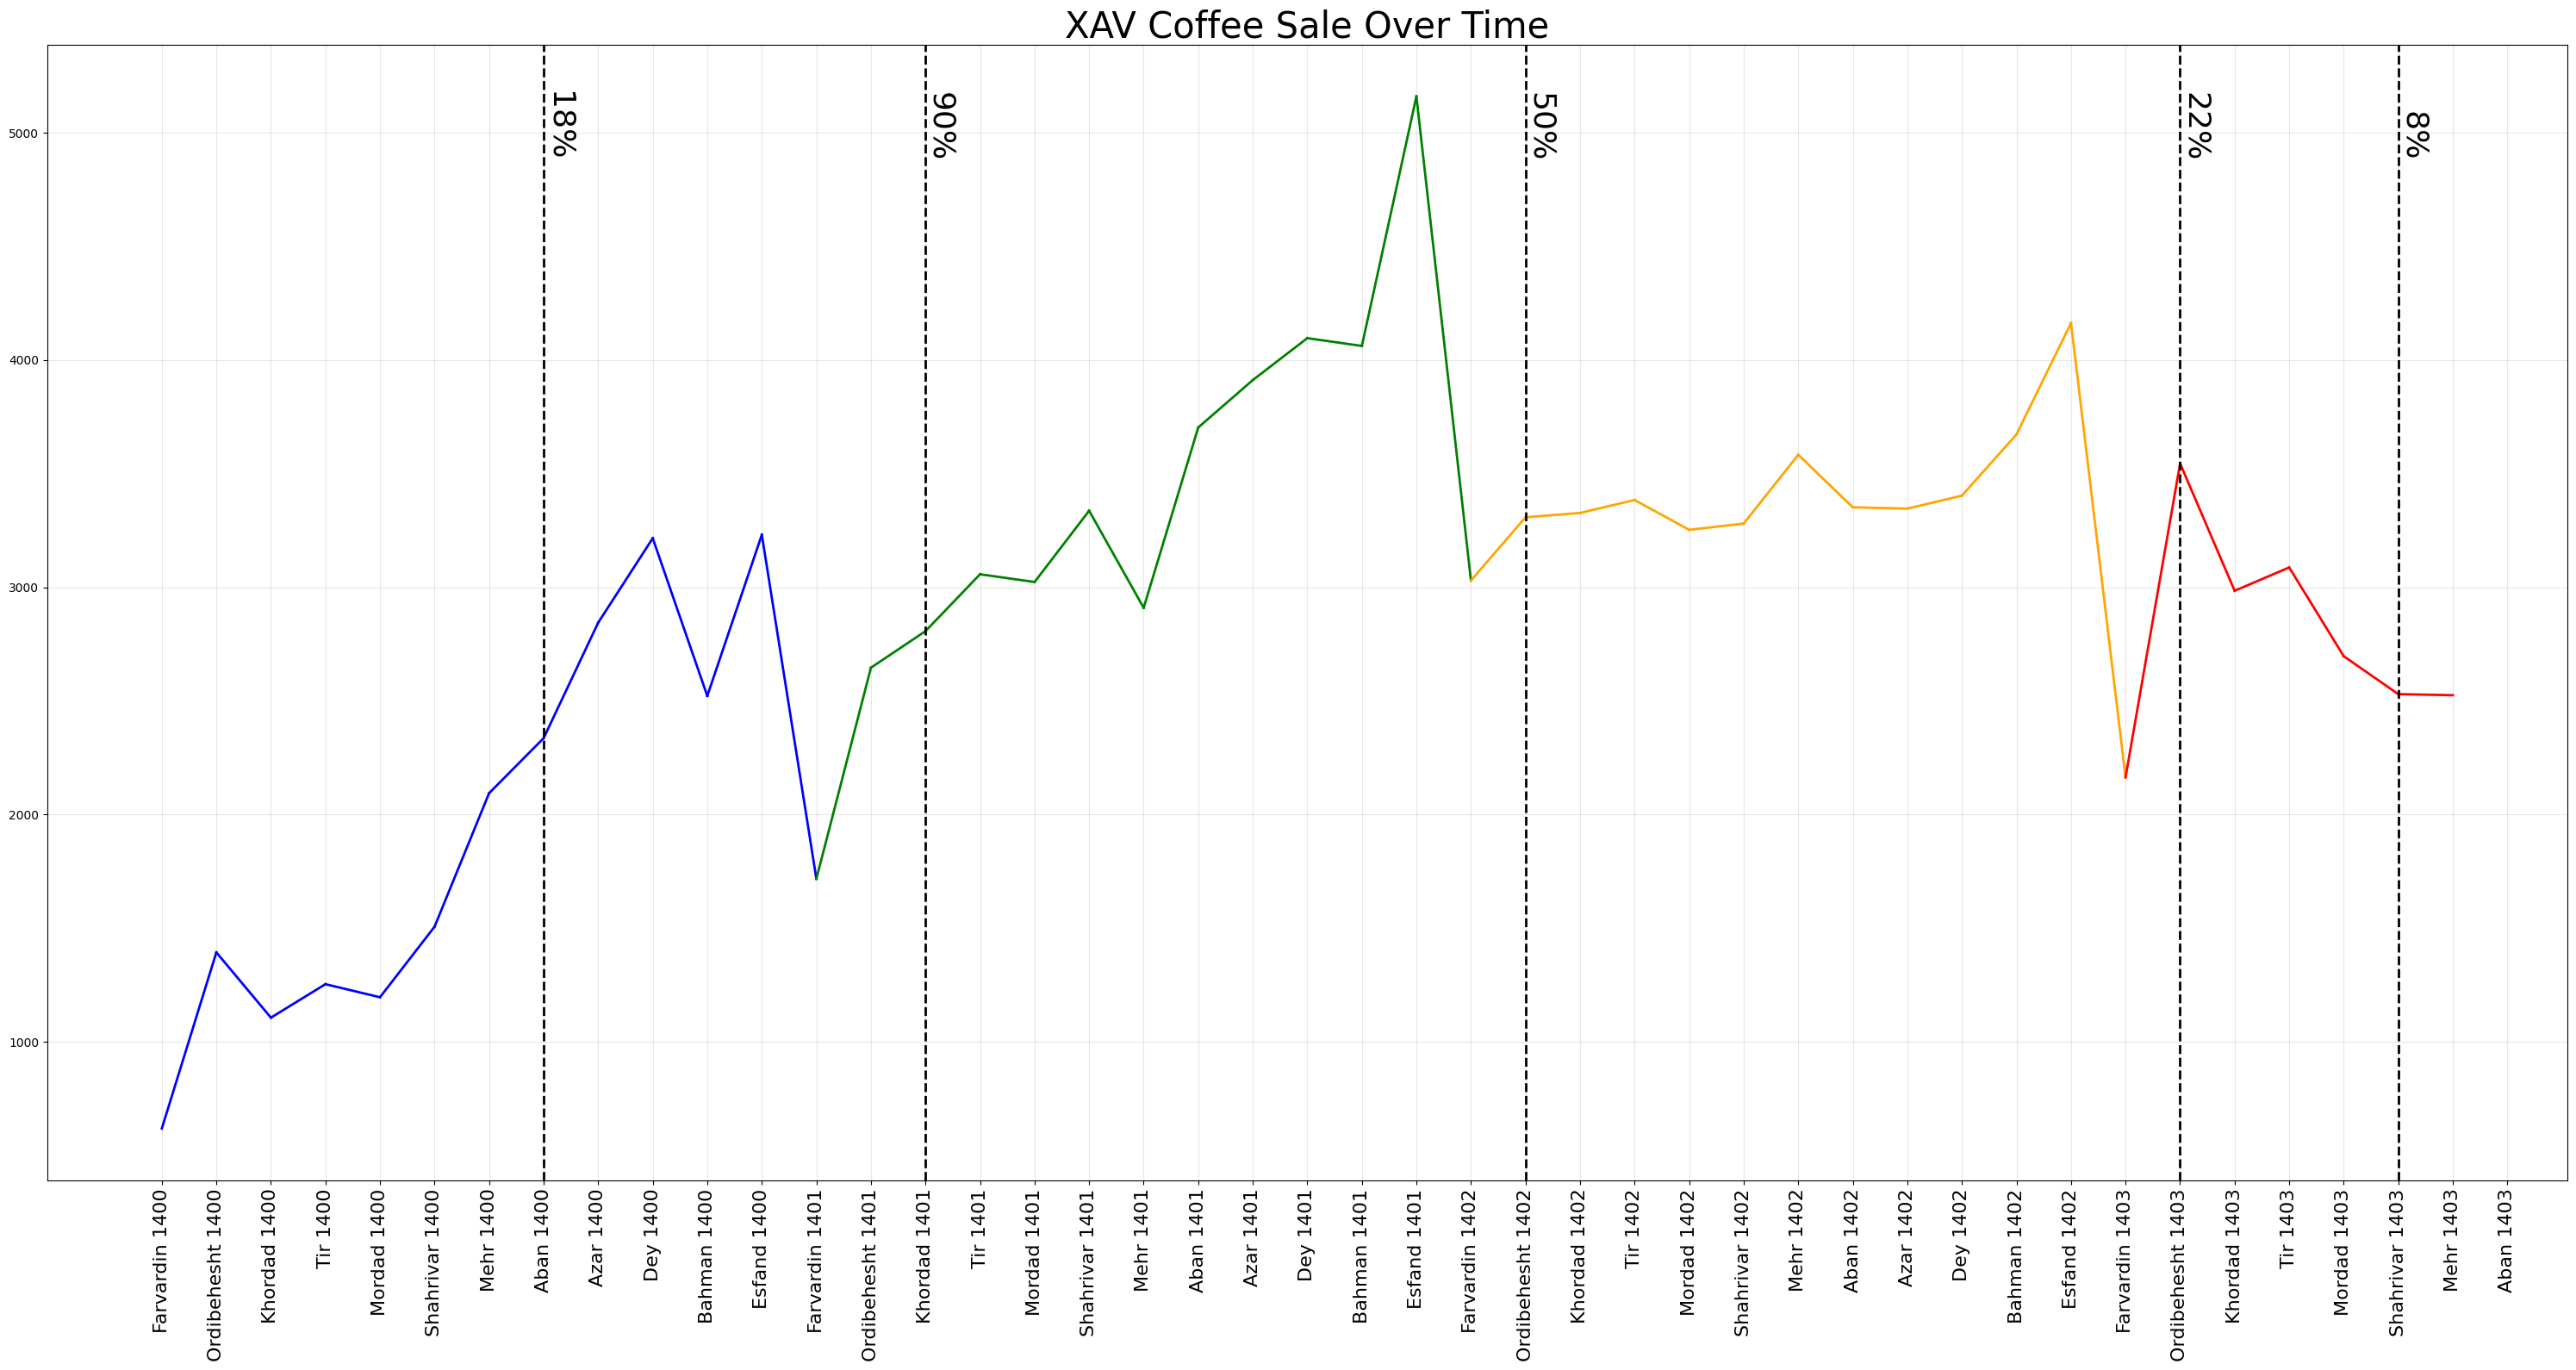

In [35]:
import matplotlib.pyplot as plt

# Define event dates and their corresponding month positions in the data
event_dates = {"18%": 7,
               "90%" : 14,
               "50%" : 25,
               "22%" : 37,
               "8%" : 41}


# creating a def to create a dict for each year ({month : kg})
def monthly_buy(year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # adding Each month kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"]==i]["مقدار-فرعي"].to_list())/1000,3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())
monthly_kg_1402 = list(monthly_buy("1402").values())
monthly_kg_1401 = list(monthly_buy("1401").values())
monthly_kg_1400 = list(monthly_buy("1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }

# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban"]

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )


# Add vertical lines for event dates
for event, index in event_dates.items():
    plt.axvline(x=index, color='black', linestyle='--', linewidth=2)
    plt.text(
        index, 
        max(all_kg) * 0.95, 
        event, 
        color='black', 
        fontsize=26, 
        ha='left', 
        rotation=-90
    )

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=30)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# Events and sale relation

In [39]:
import jdatetime
import pandas as pd
from datetime import timedelta

# Convert Persian date strings to Gregorian datetime
def convert_persian_to_gregorian(date_str):
    y, m, d = map(int, date_str.split('/'))
    return jdatetime.date(year=y, month=m, day=d).togregorian()

# Apply conversion to your DataFrame
df["Gregorian_Date"] = df["تاريخ"].apply(convert_persian_to_gregorian)

# Define a function for lagged analysis
def lagged_impact(event_date, df, lag_days=30):
    event_date = convert_persian_to_gregorian(event_date)  # Convert Persian date to Gregorian
    pre_event = df[(df["Gregorian_Date"] >= (event_date - timedelta(days=lag_days))) & 
                   (df["Gregorian_Date"] < event_date)]
    post_event_short = df[(df["Gregorian_Date"] > event_date) & 
                          (df["Gregorian_Date"] <= (event_date + timedelta(days=7)))]
    post_event_medium = df[(df["Gregorian_Date"] > event_date + timedelta(days=7)) & 
                           (df["Gregorian_Date"] <= (event_date + timedelta(days=30)))]
    
    pre_sales = pre_event["مقدار-فرعي"].sum()
    post_sales_short = post_event_short["مقدار-فرعي"].sum()
    post_sales_medium = post_event_medium["مقدار-فرعي"].sum()
    
    return {
        "pre_sales": pre_sales,
        "post_sales_short": post_sales_short,
        "post_sales_medium": post_sales_medium,
        "short_term_change": ((post_sales_short - pre_sales) / pre_sales) * 100 if pre_sales else None,
        "medium_term_change": ((post_sales_medium - pre_sales) / pre_sales) * 100 if pre_sales else None
    }

# Analyze all events
event_dates = ["1401/02/15", "1401/02/16", "1401/02/18", "1401/02/19", "1401/02/25", 
               "1402/04/05", "1402/05/10", "1402/05/13", "1402/06/03", "1402/08/05",
               "1403/07/12", "1403/08/04"]

lagged_metrics = {event: lagged_impact(event, df) for event in event_dates}

lagged_metrics

{'1401/02/15': {'pre_sales': 1804195.0,
  'post_sales_short': 788455.0,
  'post_sales_medium': 2310785.0,
  'short_term_change': -56.29879253628349,
  'medium_term_change': 28.07845050008452},
 '1401/02/16': {'pre_sales': 1727445.0,
  'post_sales_short': 794105.0,
  'post_sales_medium': 2305135.0,
  'short_term_change': -54.030084894164496,
  'medium_term_change': 33.44187513929532},
 '1401/02/18': {'pre_sales': 1793965.0,
  'post_sales_short': 781730.0,
  'post_sales_medium': 2153555.0,
  'short_term_change': -56.42445644145789,
  'medium_term_change': 20.04442673073332},
 '1401/02/19': {'pre_sales': 2017320.0,
  'post_sales_short': 774480.0,
  'post_sales_medium': 2086120.0,
  'short_term_change': -61.60847064422105,
  'medium_term_change': 3.4104653698966945},
 '1401/02/25': {'pre_sales': 2015125.0,
  'post_sales_short': 597715.0,
  'post_sales_medium': 2391940.0,
  'short_term_change': -70.33856460517339,
  'medium_term_change': 18.69933626946219},
 '1402/04/05': {'pre_sales': 3167

## Events On Sale Calender

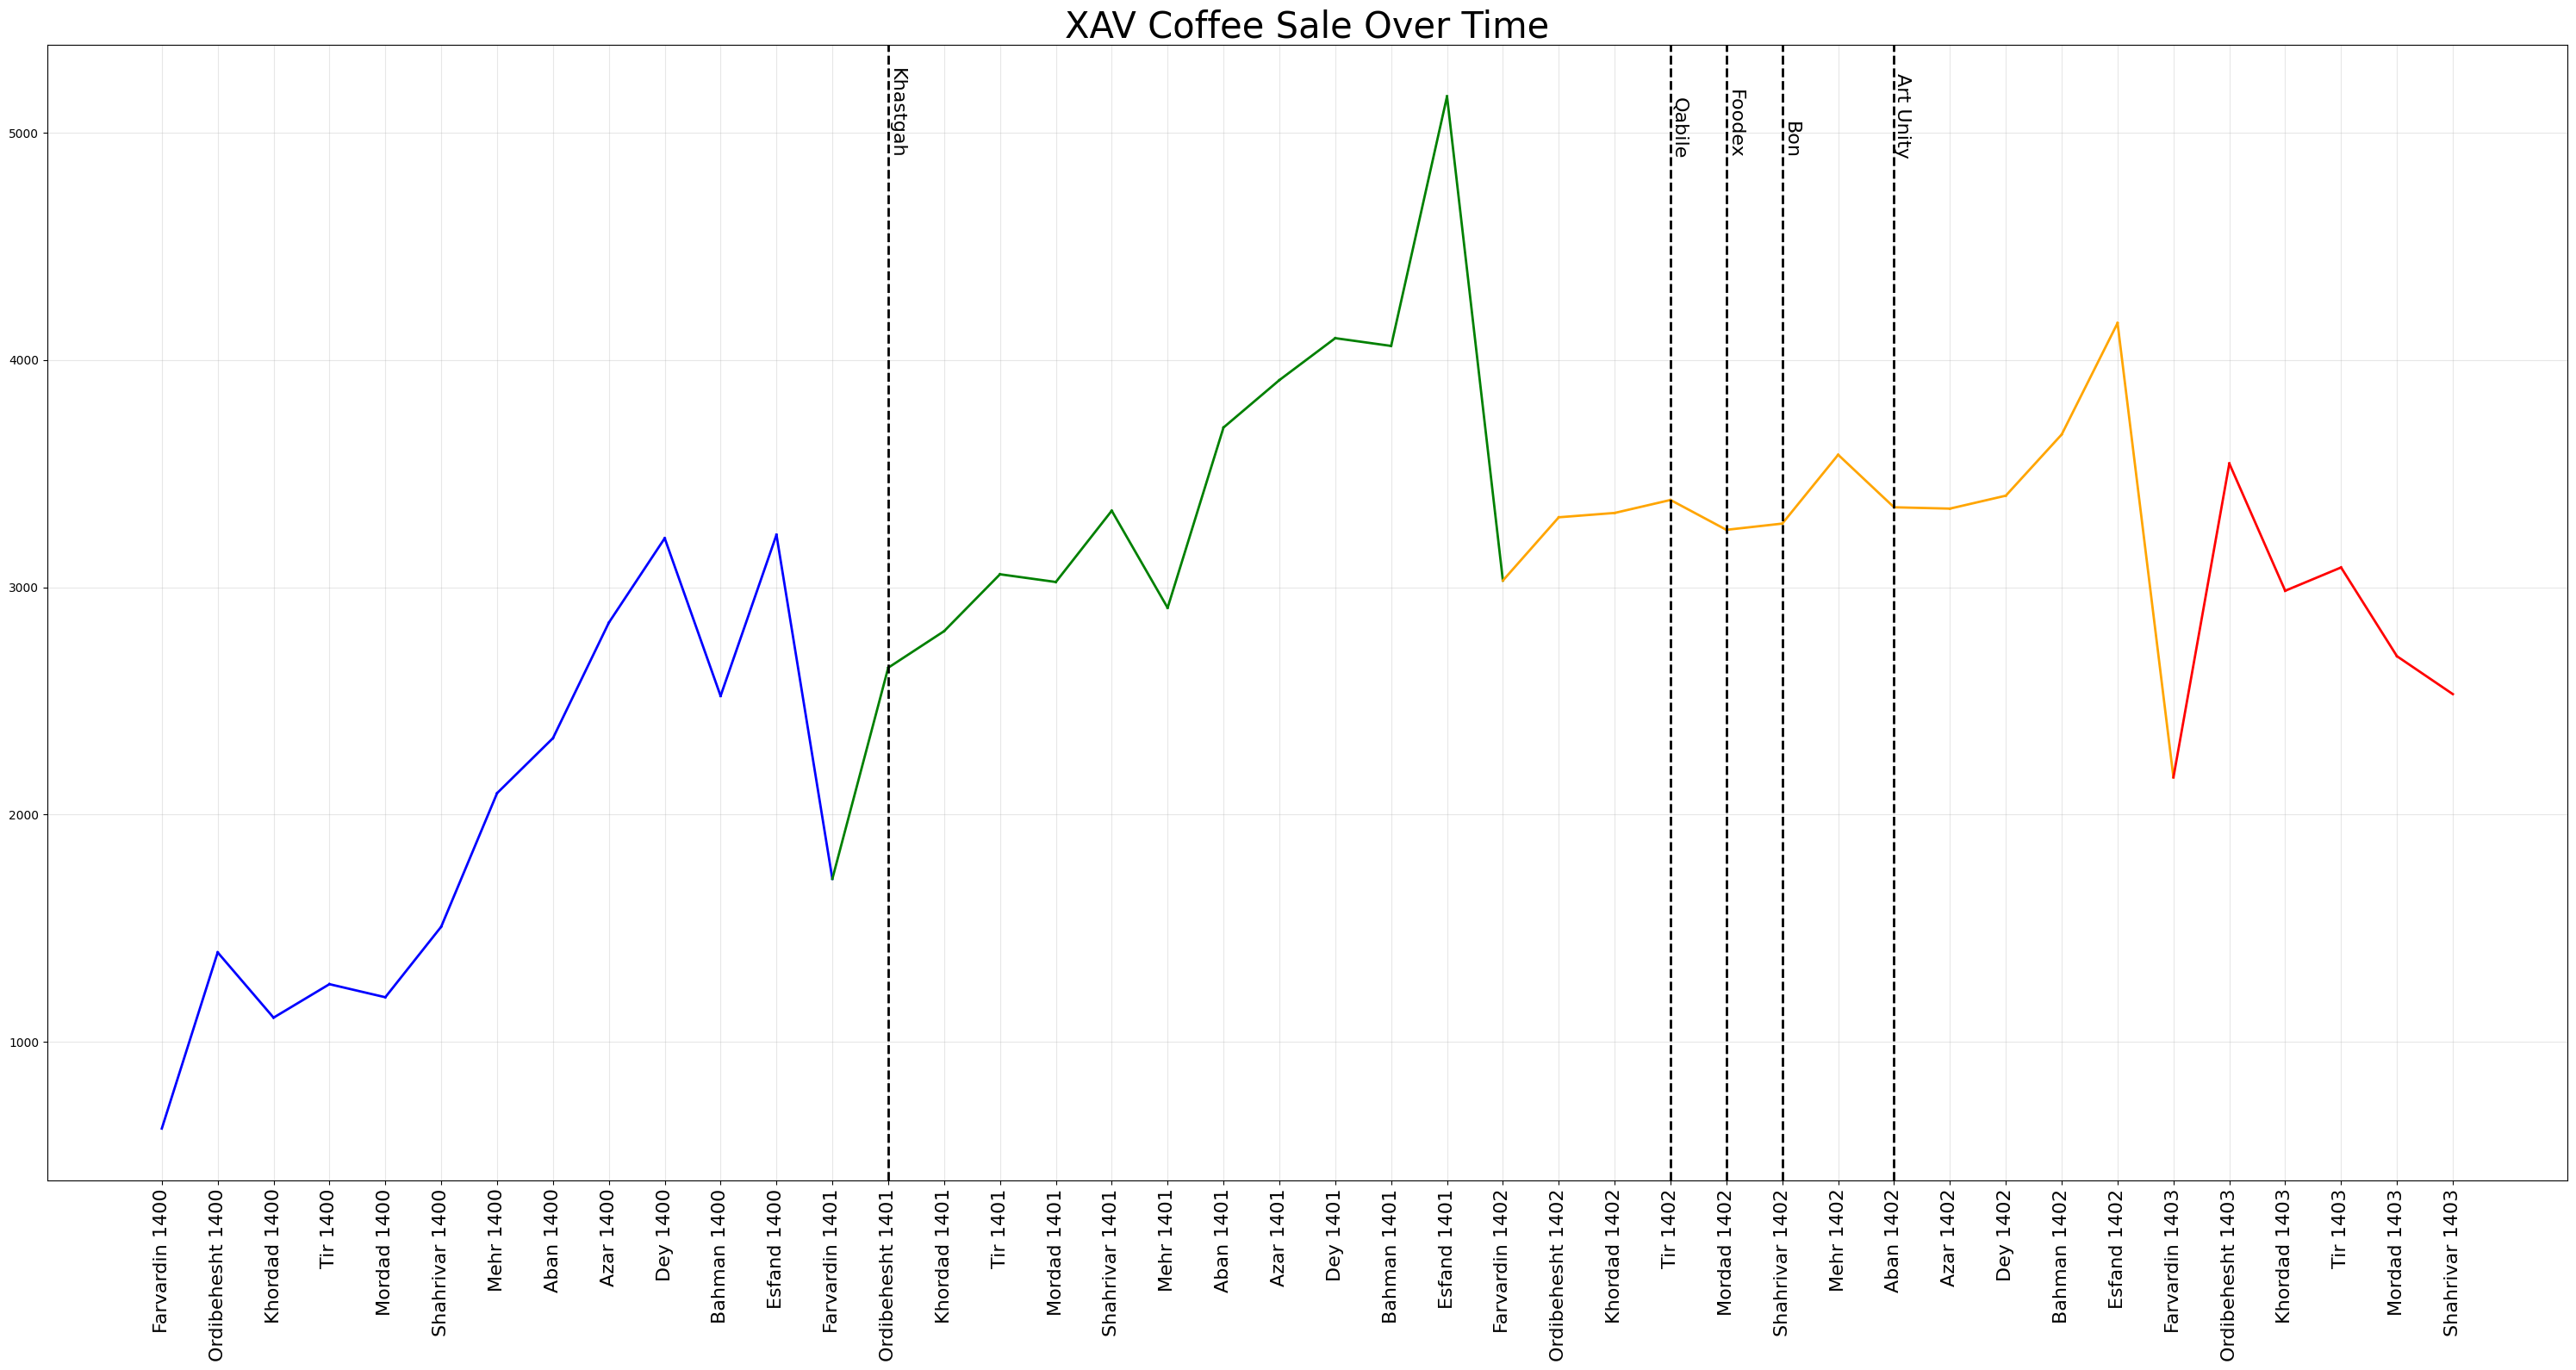

In [65]:
import matplotlib.pyplot as plt

# Define event dates and their corresponding month positions in the data
event_dates = {
    'Khastgah': 13,  
    'Qabile': 27,  
    'Foodex': 28, 
    'Bon': 29,  
    'Art Unity': 31 ,
    'Diva' : 
      
}

# creating a def to create a dict for each year ({month : kg})
def monthly_buy(year):
    year_dict = {}
    mask_year = df["تاريخ"].str.startswith(year)
    df_year = df[mask_year]
    df_year = df_year[df_year["نوع فروش"] == "قهوه و لوازم جانبي"]

    # months list 
    months_list = list(set(df_year["ماه"].to_list()))
    # adding Each month kg sale to dict
    for i in months_list:
        kg = round(sum(df_year[df_year["ماه"]==i]["مقدار-فرعي"].to_list())/1000,3)
        year_dict[i] = kg
    return year_dict

monthly_kg_1403 = list(monthly_buy("1403").values())
monthly_kg_1402 = list(monthly_buy("1402").values())
monthly_kg_1401 = list(monthly_buy("1401").values())
monthly_kg_1400 = list(monthly_buy("1400").values())

yearly_kg_dict = {1400: monthly_kg_1400, 1401:monthly_kg_1401, 1402:monthly_kg_1402 , 1403:monthly_kg_1403 }

# Persian month names
months = ['Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar', "Mehr", "Aban", "Azar", "Dey", "Bahman", 'Esfand',
          'Farvardin', 'Ordibehesht', 'Khordad', 'Tir', 'Mordad', 'Shahrivar']

plt.figure(figsize=(30, 16))

# Prepare continuous data across all years
all_months = []
all_kg = []
colors = []  # Color mapping for different years
year_colors = {
    1400: 'blue',
    1401: 'green',
    1402: 'orange',
    1403: 'red'
}

for year, monthly_data in yearly_kg_dict.items():
    all_months.extend([f"{month} {year}" for month in months[:len(monthly_data)]])
    all_kg.extend(monthly_data)
    colors.extend([year_colors[year]] * len(monthly_data))

# Plot the continuous line connecting all months
for i in range(len(all_kg) - 1):
    plt.plot(
        [i, i + 1], 
        [all_kg[i], all_kg[i + 1]], 
        color=colors[i], 
        linewidth=2
    )


# Add vertical lines for event dates
for event, index in event_dates.items():
    plt.axvline(x=index, color='black', linestyle='--', linewidth=2)
    plt.text(
        index, 
        max(all_kg) * 0.95, 
        event, 
        color='black', 
        fontsize=16, 
        ha='left', 
        rotation=-90
    )

# Adjust x-axis with Persian month labels
plt.xticks(range(len(all_months)), all_months, rotation=90, fontsize=16)

# Add labels, title, grid, and legend
plt.title("XAV Coffee Sale Over Time", fontsize=30)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


## New non-cafe customers before and after the event

## New Customers in each city (growth of sale on that area)